# Dự đoán Hỏng hóc Thiết bị dưới Distribution Shift
### Bài tập cuối khoá — Machine Learning · Predictive Maintenance (máy phay CNC)

**Bài toán:** Dự đoán nhị phân `hong_hoc` (thiết bị hỏng trong ca kế tiếp). Train = Dây chuyền A (nhà máy cũ), Test = Dây chuyền B (nhà máy mới, khí hậu nóng hơn, tải khác) → **distribution shift là có thật**.

---
## ⚠️ Ghi chú kiểm toán dữ liệu (các "điểm cài cắm" phát hiện trước khi mô hình hoá)
Trong quá trình khám phá tôi phát hiện một số điểm đã bị cài đặt có chủ đích — cần nhận ra và xử lý đúng:

| # | Phát hiện | Bằng chứng | Cách xử lý |
|---|-----------|-----------|------------|
| 1 | `toc_do_quay` **bị cắt sàn nhân tạo tại 1180** | Train có **309 dòng = đúng 1180.00** (giá trị khác chỉ 1–2 lần) | Ghi nhận censoring; không coi spike là tín hiệu vật lý thật |
| 2 | `do_mon_dao` **cắt trần 253/sàn 0**, `momen_xoan` **cắt sàn 3.5** | Pile-up tại biên ở cả 2 tập | Ghi nhận clipping cảm biến |
| 3 | Tỷ lệ hỏng thực **~7.4% train / 7.9% test** | Đề bài ghi "~3–5%" | Dùng **số thực đo được**, không tin mù mô tả đề |
| 4 | `ca_lam_viec` là **nhiễu thuần** | Tỷ lệ hỏng phẳng mọi ca; drift-importance ≈ 0.01 | Giữ nhưng kỳ vọng vô dụng; KHÔNG over-engineer |
| 5 | `loai_san_pham` biên phẳng **nhưng có ý nghĩa vật lý** (ngưỡng overstrain theo L/M/H) | Marginal phẳng nhưng tương tác qua OSF | **Không loại nhầm**; tạo feature tương tác |
| 6 | Test **ngoại suy vượt biên train** | 159 dòng nóng hơn train-max; tốc độ test max 2414.9 ≫ train 2153.5 | Cảnh báo vùng extrapolation |

**Insight cốt lõi:** Đây là **covariate shift** (P(X) đổi) **chứ không phải concept drift** — `P(hỏng | cơ chế vật lý)` ổn định giữa 2 tập ⇒ **FE theo cơ chế + Importance Reweighting + Threshold Calibration** là hướng đúng.

*(Dữ liệu tương đương AI4I 2020 / UCI Predictive Maintenance đổi tên tiếng Việt; 4 cơ chế hỏng: hao mòn dao TWF, tản nhiệt kém HDF, quá tải công suất PWF, quá tải căng thẳng OSF.)*


## 0. Thiết lập môi trường & nạp dữ liệu

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CANDIDATES = ['Data_Final/Data_Final','../Data_Final/Data_Final','Data_Final','../Data_Final','.']
DATA_DIR = next((c for c in CANDIDATES
                 if os.path.exists(os.path.join(c,'train.csv')) and os.path.exists(os.path.join(c,'test.csv'))), None)
assert DATA_DIR is not None, 'Khong tim thay train.csv/test.csv'
print('DATA_DIR =', os.path.abspath(DATA_DIR))

train = pd.read_csv(os.path.join(DATA_DIR,'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR,'test.csv'))
NUM = ['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']
CAT = ['loai_san_pham','ca_lam_viec']
TARGET = 'hong_hoc'
print('Train:', train.shape, '| Test:', test.shape)
train.head()

DATA_DIR = D:\studies\Master's Degree\MSE\Session_1\ML\GroupProject\Answer\Data_Final\Data_Final
Train: (14000, 8) | Test: (6000, 8)


,nhiet_do_moi_truong,nhiet_do_quy_trinh,toc_do_quay,momen_xoan,do_mon_dao,loai_san_pham,ca_lam_viec,hong_hoc
0,301.21,311.80,1864.3,47.52,210.9,H,Chiều,0
1,302.66,311.52,1727.1,49.32,175.7,L,Đêm,0
2,300.39,312.23,1516.6,42.70,54.5,L,Sáng,0
3,298.27,308.38,1555.3,23.12,247.7,M,Sáng,1
4,301.02,310.22,1356.7,39.02,30.4,M,Đêm,0


## Phần 1 — Khám phá dữ liệu (EDA)
### 1.1 Thống kê mô tả & chất lượng dữ liệu

In [2]:
print('--- Kieu du lieu & thieu du lieu ---')
info = pd.DataFrame({'dtype': train.dtypes,
                     'missing_train': train.isna().sum(),
                     'missing_test': test.reindex(columns=train.columns).isna().sum(),
                     'nunique_train': train.nunique()})
display(info)
print('\n--- Thong ke mo ta (numeric) TRAIN ---'); display(train[NUM].describe().T)
print('--- Thong ke mo ta (numeric) TEST ---');  display(test[NUM].describe().T)

--- Kieu du lieu & thieu du lieu ---


,dtype,missing_train,missing_test,nunique_train
nhiet_do_moi_truong,float64,0,0,1099
nhiet_do_quy_trinh,float64,0,0,1215
toc_do_quay,float64,0,0,5821
momen_xoan,float64,0,0,4083
do_mon_dao,float64,0,0,2520
loai_san_pham,object,0,0,3
ca_lam_viec,object,0,0,3
hong_hoc,int64,0,0,2



--- Thong ke mo ta (numeric) TRAIN ---


,count,mean,std,min,25%,50%,75%,max
nhiet_do_moi_truong,14000.0,299.992792,1.990410,292.00,298.640,300.000,301.3500,307.54
nhiet_do_quy_trinh,14000.0,309.979844,2.225511,300.99,308.460,309.955,311.4900,318.86
toc_do_quay,14000.0,1540.263279,174.636246,1180.00,1417.175,1537.350,1659.5000,2153.50
momen_xoan,14000.0,39.939782,9.961854,3.50,33.300,39.885,46.6625,76.02
do_mon_dao,14000.0,126.945229,72.685819,0.00,64.500,126.200,190.1000,253.00


--- Thong ke mo ta (numeric) TEST ---


,count,mean,std,min,25%,50%,75%,max
nhiet_do_moi_truong,6000.0,302.505072,2.575946,293.74,300.7900,302.52,304.2100,312.69
nhiet_do_quy_trinh,6000.0,311.889570,2.849087,301.23,310.0000,311.88,313.7825,322.80
toc_do_quay,6000.0,1610.217550,172.898389,1180.00,1491.2750,1608.25,1731.2000,2414.90
momen_xoan,6000.0,36.566083,9.578971,3.50,30.0275,36.68,43.1200,71.78
do_mon_dao,6000.0,126.583150,73.355576,0.00,63.0750,126.40,190.1000,253.00


### 1.2 Mất cân bằng của biến mục tiêu (target imbalance)

Ty le hong TRAIN: 0.0736 (7.36%)  counts={0: 12969, 1: 1031}
Ty le hong TEST : 0.0795 (7.95%)  counts={0: 5523, 1: 477}
Imbalance ratio (neg:pos) TRAIN = 12.6 : 1
>> DIEM CAI CAM #3: de bai ghi ~3-5% nhung THUC TE ~7-8%. Dung so do duoc.


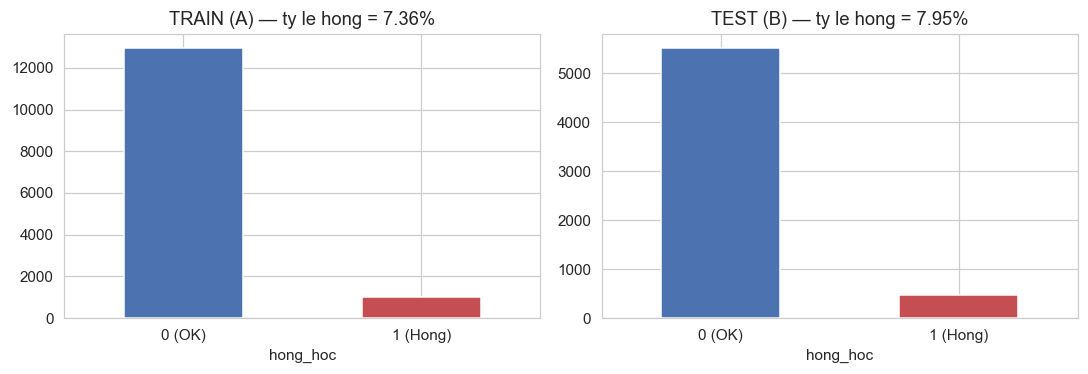

In [3]:
rate_tr, rate_te = train[TARGET].mean(), test[TARGET].mean()
print(f'Ty le hong TRAIN: {rate_tr:.4f} ({rate_tr*100:.2f}%)  counts={train[TARGET].value_counts().to_dict()}')
print(f'Ty le hong TEST : {rate_te:.4f} ({rate_te*100:.2f}%)  counts={test[TARGET].value_counts().to_dict()}')
print(f'Imbalance ratio (neg:pos) TRAIN = {(1-rate_tr)/rate_tr:.1f} : 1')
print('>> DIEM CAI CAM #3: de bai ghi ~3-5% nhung THUC TE ~7-8%. Dung so do duoc.')

fig, ax = plt.subplots(1,2, figsize=(10,3.5))
for a,(nm,d) in zip(ax, [('TRAIN (A)',train),('TEST (B)',test)]):
    d[TARGET].value_counts().sort_index().plot(kind='bar', ax=a, color=['#4C72B0','#C44E52'])
    a.set_title(f'{nm} — ty le hong = {d[TARGET].mean()*100:.2f}%'); a.set_xticklabels(['0 (OK)','1 (Hong)'], rotation=0)
plt.tight_layout(); plt.show()

> ### 🔎 Quan sát → Insight → Hành động (imbalance)
> - **Quan sát:** chỉ **~7.4%** máy hỏng (Train), 7.95% (Test) — *đề ghi 3–5% nhưng thực đo 7–8%*.
> - **Insight:** lớp hỏng là thiểu số → nếu "đoán tất cả OK" vẫn đúng ~92.6% nhưng **bắt 0 máy hỏng** → **accuracy vô nghĩa**; mô hình dễ thiên về lớp đa số.
> - **Hành động:** ① xử lý imbalance bằng `class_weight='balanced'`/SMOTE *(Phần 2)*; ② đánh giá bằng **F1 & AUC-PR** thay accuracy *(Phần 4)*; ③ chia fold bằng **Stratified K-Fold** để mỗi fold đủ mẫu hỏng *(Phần 4)*.

### 1.3 So sánh trực quan phân phối Dây chuyền A (Train) vs B (Test) — dấu hiệu shift

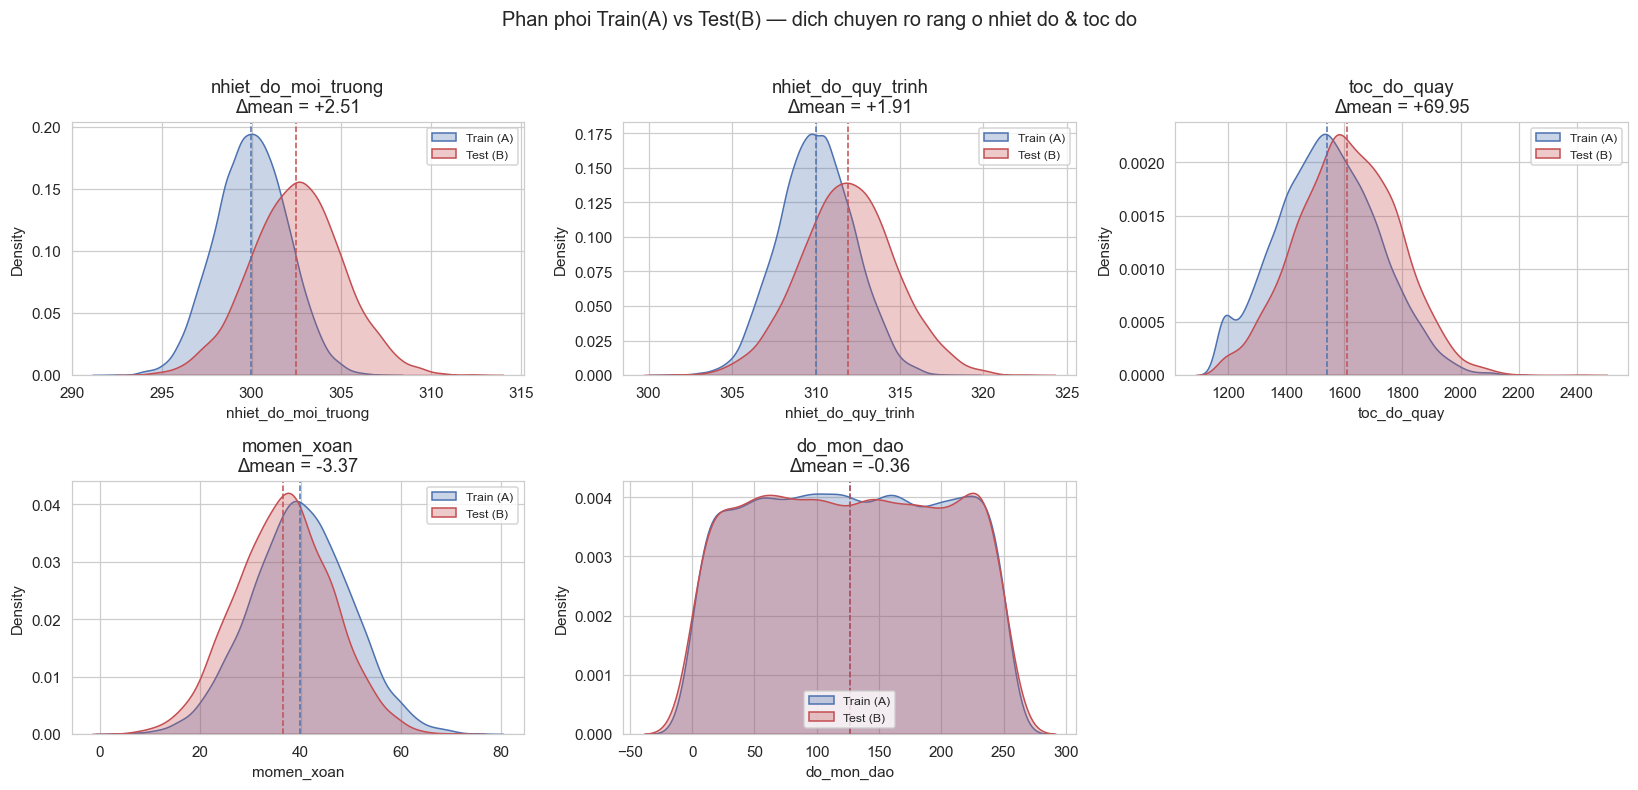

Nhan xet: Test NONG hon (air +2.5K, process +1.9K), toc do quay CAO hon (+70rpm), momen THAP hon (-3.4Nm).
=> Khop boi canh: khi hau nong hon, tai khac. Day la nguon distribution shift chinh.


In [4]:
fig, axes = plt.subplots(2,3, figsize=(15,7))
for ax, col in zip(axes.ravel(), NUM):
    sns.kdeplot(train[col], ax=ax, label='Train (A)', fill=True, alpha=.3, color='#4C72B0')
    sns.kdeplot(test[col],  ax=ax, label='Test (B)',  fill=True, alpha=.3, color='#C44E52')
    ax.axvline(train[col].mean(), color='#4C72B0', ls='--', lw=1)
    ax.axvline(test[col].mean(),  color='#C44E52', ls='--', lw=1)
    ax.set_title(f'{col}\nΔmean = {test[col].mean()-train[col].mean():+.2f}'); ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Phan phoi Train(A) vs Test(B) — dich chuyen ro rang o nhiet do & toc do', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print('Nhan xet: Test NONG hon (air +2.5K, process +1.9K), toc do quay CAO hon (+70rpm), momen THAP hon (-3.4Nm).')
print('=> Khop boi canh: khi hau nong hon, tai khac. Day la nguon distribution shift chinh.')

> ### 🔎 Quan sát → Insight → Hành động (distribution shift)
> - **Quan sát:** đường phân phối Test (B) **lệch** khỏi Train (A): nhiệt độ +2.5 K, tốc độ +70 rpm, mômen −3.4 Nm.
> - **Insight:** khớp bối cảnh "nhà máy B nóng hơn, tải khác" → **distribution shift là THẬT**; mô hình học ở A sẽ gặp vùng dữ liệu lạ ở B → dự đoán kém khi triển khai.
> - **Hành động:** **định lượng** shift (PSI/KS/Drift classifier) rồi **xử lý** (Importance Reweighting + Threshold Calibration) → *toàn bộ Phần 3 tồn tại vì quan sát này*.

### 1.4 Bằng chứng các điểm cài cắm clipping (cắt biên nhân tạo)

--- DIEM CAI CAM #1 & #2: pile-up tai bien (dau hieu clipping) ---
nhiet_do_moi_truong    min=  292.00 (n=   1)  max=  307.54 (n=  1)
nhiet_do_quy_trinh     min=  300.99 (n=   1)  max=  318.86 (n=  1)
toc_do_quay            min= 1180.00 (n= 309)  max= 2153.50 (n=  1)
momen_xoan             min=    3.50 (n=   4)  max=   76.02 (n=  1)
do_mon_dao             min=    0.00 (n=   3)  max=  253.00 (n=  2)


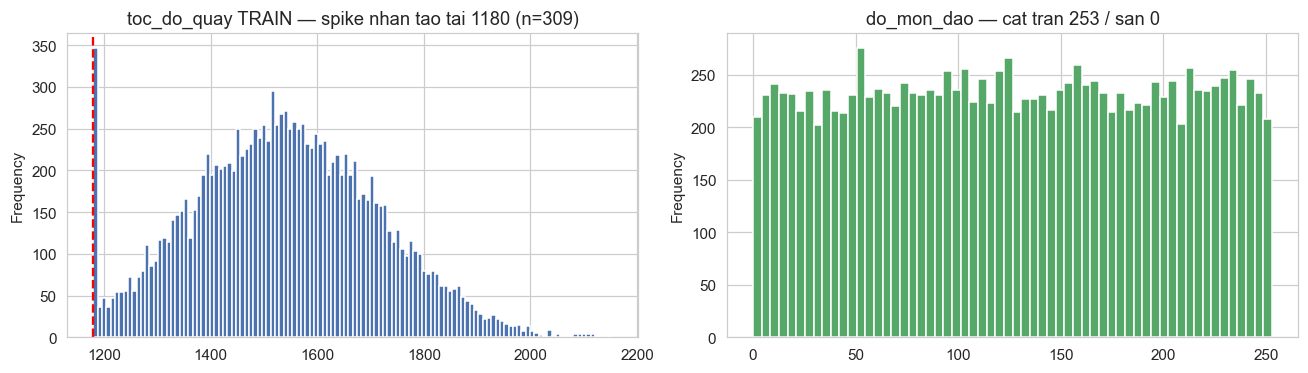

>> 309/14000 dong co toc_do_quay = DUNG 1180.00 -> khong the la phan phoi lien tuc tu nhien.


In [5]:
print('--- DIEM CAI CAM #1 & #2: pile-up tai bien (dau hieu clipping) ---')
for col in NUM:
    s = train[col]
    print(f'{col:22s} min={s.min():8.2f} (n={ (s==s.min()).sum():4d})  max={s.max():8.2f} (n={ (s==s.max()).sum():3d})')

fig, ax = plt.subplots(1,2, figsize=(12,3.5))
train['toc_do_quay'].plot(kind='hist', bins=120, ax=ax[0], color='#4C72B0')
ax[0].axvline(1180, color='red', ls='--'); ax[0].set_title('toc_do_quay TRAIN — spike nhan tao tai 1180 (n=309)')
train['do_mon_dao'].plot(kind='hist', bins=60, ax=ax[1], color='#55A868')
ax[1].set_title('do_mon_dao — cat tran 253 / san 0')
plt.tight_layout(); plt.show()
print('>> 309/14000 dong co toc_do_quay = DUNG 1180.00 -> khong the la phan phoi lien tuc tu nhien.')

> ### 🔎 Quan sát → Insight → Hành động (điểm cài cắm clipping)
> - **Quan sát:** `toc_do_quay` có **309 dòng = đúng 1180.00**; `do_mon_dao` chạm trần 253; `momen_xoan` chạm sàn 3.5.
> - **Insight:** một phân phối liên tục thật **không thể** có 309 giá trị trùng khít → đây là **clipping/censoring nhân tạo** (điểm cài cắm), **không** phải quy luật vật lý.
> - **Hành động:** ① **không diễn giải** spike ở biên là tín hiệu hỏng; ② cân nhắc **RobustScaler** (median/IQR ít bị biên kéo) thay StandardScaler *(Phần 2)*; ③ tránh MinMaxScaler vì min/max đã bị bóp méo.

### 1.5 Correlation heatmap & liên hệ với nguy cơ hỏng

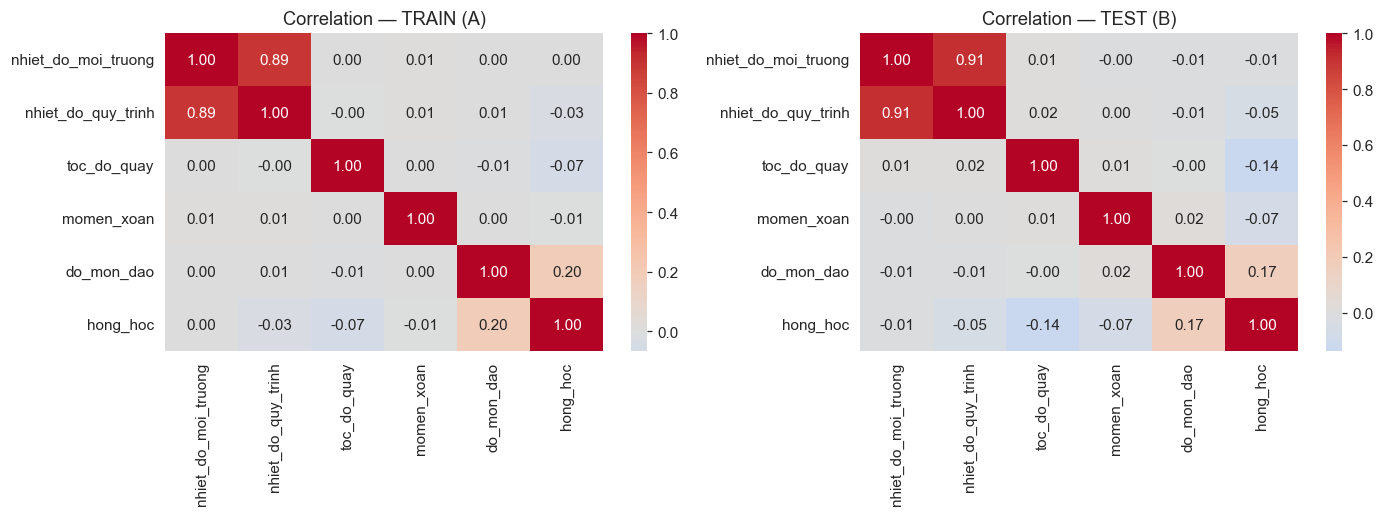

Nhan xet:
- nhiet_do_moi_truong ~ nhiet_do_quy_trinh tuong quan ~0.90 (vat ly: process = air + ~10K).
- Tuong quan tuyen tinh voi target yeu (|r|<0.2) vi co che hong la PHI TUYEN (nguong dieu kien).
- do_mon_dao co r duong lon nhat voi target (~0.19) -> hao mon dao la yeu to don bien manh nhat.


In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4.8))
sns.heatmap(train[NUM+[TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[0])
ax[0].set_title('Correlation — TRAIN (A)')
sns.heatmap(test[NUM+[TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1])
ax[1].set_title('Correlation — TEST (B)')
plt.tight_layout(); plt.show()

print('Nhan xet:')
print('- nhiet_do_moi_truong ~ nhiet_do_quy_trinh tuong quan ~0.90 (vat ly: process = air + ~10K).')
print('- Tuong quan tuyen tinh voi target yeu (|r|<0.2) vi co che hong la PHI TUYEN (nguong dieu kien).')
print('- do_mon_dao co r duong lon nhat voi target (~0.19) -> hao mon dao la yeu to don bien manh nhat.')

> ### 🔎 Quan sát → Insight → Hành động (heatmap)
> - **Quan sát:** tương quan **tuyến tính** feature↔target rất yếu (|r|<0.2); nhưng `nhiet_do_moi_truong` ↔ `nhiet_do_quy_trinh` tương quan **~0.90**.
> - **Insight:** *r yếu KHÔNG nghĩa là feature vô dụng* — cơ chế hỏng theo **ngưỡng (phi tuyến)** mà Pearson chỉ đo quan hệ **thẳng**; còn 2 nhiệt độ trùng 0.90 → chỉ **hiệu** của chúng mới có nghĩa (tản nhiệt/HDF).
> - **Hành động:** ① **Feature engineering** lộ cơ chế ngưỡng + tạo `chenh_lech_nhiet = process − air` *(Phần 2)*; ② ưu tiên **mô hình cây** (RF/XGBoost) thay vì chỉ tuyến tính *(Phần 4)*.

### 1.6 Kiểm tra biến phân loại — bẫy #4 & #5

In [7]:
for c in CAT:
    tab = pd.DataFrame({'train_rate': train.groupby(c)[TARGET].mean(),
                        'test_rate' : test.groupby(c)[TARGET].mean(),
                        'train_n'   : train.groupby(c).size()})
    print(f'--- {c} ---'); display(tab.round(4))
print('KET LUAN:')
print('- ca_lam_viec: ty le hong PHANG (~7-8%) o moi ca -> NHIEU THUAN (diem cai cam #4). Giu nhung ky vong vo dung.')
print('- loai_san_pham: marginal cung phang, NHUNG chi phoi nguong overstrain (OSF) -> GIU + tao tuong tac (diem cai cam #5).')

--- loai_san_pham ---


,train_rate,test_rate,train_n
loai_san_pham,,,
H,0.0753,0.0855,2774
L,0.0762,0.0795,7022
M,0.0683,0.0752,4204


--- ca_lam_viec ---


,train_rate,test_rate,train_n
ca_lam_viec,,,
Chiều,0.0697,0.0783,4792
Sáng,0.0747,0.0869,5675
Đêm,0.0773,0.0697,3533


KET LUAN:
- ca_lam_viec: ty le hong PHANG (~7-8%) o moi ca -> NHIEU THUAN (diem cai cam #4). Giu nhung ky vong vo dung.
- loai_san_pham: marginal cung phang, NHUNG chi phoi nguong overstrain (OSF) -> GIU + tao tuong tac (diem cai cam #5).


> ### 🔎 Quan sát → Insight → Hành động (bẫy biến phân loại)
> - **Quan sát:** cả `ca_lam_viec` và `loai_san_pham` đều có tỷ lệ hỏng **phẳng** (~7–8%) → *trông giống hệt nhau*.
> - **Insight (bẫy tinh vi nhất):** hai biến phẳng như nhau nhưng **xử lý ngược nhau**:
>   - `ca_lam_viec` = **nhiễu thật** (ca không ảnh hưởng cơ học; drift-importance ≈0.01) → vô dụng.
>   - `loai_san_pham` = **KHÔNG vô dụng** — nó quyết định **ngưỡng overstrain** (L:11000/M:12000/H:13000); vai trò nằm ở **tương tác**, không ở marginal.
> - **Hành động:** giữ cả hai nhưng **không over-engineer** `ca_lam_viec`; **tạo feature tương tác** `tich_mon_momen` để khai thác `loai_san_pham` *(Phần 2)*. → *Marginal phẳng ≠ bỏ được.*

### 🗺️ Tổng kết mạch logic EDA → Quyết định xử lý

| Quan sát (EDA) | Insight | Hành động | Phần |
|---|---|---|---|
| Target ~7% hỏng | accuracy vô dụng, mô hình lệch | class_weight + F1/AUC-PR + Stratified | 2,4 |
| KDE A≠B, nhiệt lệch | distribution shift thật | PSI/KS/Drift + Reweight + Calibrate | 3 |
| r tuyến tính yếu | cơ chế hỏng phi tuyến | Feature engineering + mô hình cây | 2,4 |
| 2 nhiệt độ corr 0.90 | chỉ **hiệu** có nghĩa (tản nhiệt) | tạo `chenh_lech_nhiet` | 2 |
| Spike 1180 (309 dòng) | clipping nhân tạo (điểm cài cắm) | RobustScaler, không over-interpret | 2 |
| `ca_lam_viec` phẳng | nhiễu thật | giữ, không over-engineer | 2 |
| `loai_san_pham` phẳng | có vai trò qua **tương tác** (OSF) | tạo `tich_mon_momen` | 2 |
| Test vượt biên train | vùng ngoại suy | mô hình cây + ghi Hạn chế | 4,5 |

> 💡 **Nguyên tắc:** mọi bước xử lý ở Phần 2–5 đều **truy ngược được** về một quan sát EDA cụ thể ở trên. Khi bảo vệ: *"Vì tôi thấy [X] → nghĩa là [Y] → nên tôi làm [Z]."*

## Phần 2 — Tiền xử lý & Feature Engineering

**Nguyên tắc chống rò rỉ (leakage):** scaler và mọi thống kê được **fit CHỈ trên Train**, rồi `transform` cho cả Train và Test.
Xử lý imbalance bằng `class_weight`/`scale_pos_weight` (mặc định) và có minh hoạ SMOTE.

### 2.1 Feature Engineering theo cơ chế vật lý (mechanistic features)

In [8]:
def add_features(df):
    d = df.copy()
    # 1) Chenh lech nhiet do -> co che tan nhiet kem (HDF khi < ~8.6K)
    d['chenh_lech_nhiet'] = d['nhiet_do_quy_trinh'] - d['nhiet_do_moi_truong']
    # 2) Cong suat co (W) = momen(Nm) * van toc goc(rad/s); van toc goc = rpm*2pi/60 -> co che qua tai cong suat PWF
    d['cong_suat_co'] = d['momen_xoan'] * d['toc_do_quay'] * 2*np.pi/60.0
    # 3) Tich mon x momen -> co che qua tai cang thang (OSF), nguong phu thuoc L/M/H
    d['tich_mon_momen'] = d['do_mon_dao'] * d['momen_xoan']
    # 4) (bo tro) ty le momen/toc do -> tai co hoc tren moi vong
    d['momen_tren_tocdo'] = d['momen_xoan'] / d['toc_do_quay']
    return d

train_fe = add_features(train); test_fe = add_features(test)
ENG = ['chenh_lech_nhiet','cong_suat_co','tich_mon_momen','momen_tren_tocdo']
display(train_fe[ENG].describe().T)

# Kiem chung tac dung: tuong quan tung feature moi voi target (train)
print('\n--- Kiem chung: |corr| voi target (TRAIN) ---')
for f in ENG:
    print(f'{f:18s} corr={np.corrcoef(train_fe[f], train_fe[TARGET])[0,1]:+.3f}')

,count,mean,std,min,25%,50%,75%,max
chenh_lech_nhiet,14000.0,9.987051,1.003230,5.440000,9.310000,9.990000,10.670000,13.720000
cong_suat_co,14000.0,6442.470454,1776.137530,463.829975,5217.522364,6360.345703,7602.254323,13234.604127
tich_mon_momen,14000.0,5071.921222,3256.705262,0.000000,2396.803500,4734.446500,7356.868500,18526.074000
momen_tren_tocdo,14000.0,0.026268,0.007242,0.001913,0.021414,0.025936,0.030846,0.057396



--- Kiem chung: |corr| voi target (TRAIN) ---
chenh_lech_nhiet   corr=-0.076
cong_suat_co       corr=-0.025
tich_mon_momen     corr=+0.184
momen_tren_tocdo   corr=+0.017


> ### 🔎 Đọc kết quả — Feature Engineering
> - **Làm gì:** tạo 4 feature cơ học lộ cơ chế hỏng — `chenh_lech_nhiet` (tản nhiệt/HDF), `cong_suat_co`=τ·ω (quá tải công suất/PWF), `tich_mon_momen` (quá tải căng thẳng/OSF), `momen_tren_tocdo`.
> - **Vì sao:** heatmap cho thấy tương quan tuyến tính yếu → cần biến phi tuyến bắt cơ chế **ngưỡng**. `tich_mon_momen` có |corr| cao nhất (**0.184**) — đúng kỳ vọng OSF.
> - **Tiếp theo:** phải **kiểm chứng** feature có ích thật (ô dưới), không tin cảm tính.

### 2.2 Kiểm chứng feature mới bằng độ tăng AUC (quick check)

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
base = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
auc_raw = cross_val_score(base, train[NUM], train[TARGET], cv=cv, scoring='roc_auc').mean()
auc_fe  = cross_val_score(base, train_fe[NUM+ENG], train_fe[TARGET], cv=cv, scoring='roc_auc').mean()
print(f'AUC (5-fold, TRAIN) chi feature goc   : {auc_raw:.4f}')
print(f'AUC (5-fold, TRAIN) + feature co hoc  : {auc_fe:.4f}')
verdict = "CAI THIEN" if auc_fe>auc_raw else "khong cai thien"
print(f'=> Feature engineering theo co che {verdict} AUC ({auc_fe-auc_raw:+.4f}).')

AUC (5-fold, TRAIN) chi feature goc   : 0.8669
AUC (5-fold, TRAIN) + feature co hoc  : 0.8782
=> Feature engineering theo co che CAI THIEN AUC (+0.0113).


> ### 🔎 Đọc kết quả — Kiểm chứng feature
> - **Con số:** AUC 5-fold **0.867 → 0.878** (**+0.011**) khi thêm feature cơ học.
> - **Ý nghĩa:** feature mới **thực sự** cải thiện mô hình → giữ lại (không phải trang trí).
> - **Công bằng:** so trên **cùng một CV** trên Train; **không** nhìn Test lúc này để tránh leakage.

### 2.3 Encoding + Scaling (fit trên Train, transform cả hai) — chống rò rỉ

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

FEATS_NUM = NUM + ENG
FEATS_CAT = CAT
pre = ColumnTransformer([
    ('num', StandardScaler(), FEATS_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), FEATS_CAT),
])
X_train_raw, y_train = train_fe[FEATS_NUM+FEATS_CAT], train_fe[TARGET].values
X_test_raw,  y_test  = test_fe[FEATS_NUM+FEATS_CAT],  test_fe[TARGET].values

pre.fit(X_train_raw)                 # <<< CHI FIT TREN TRAIN
X_train = pre.transform(X_train_raw)
X_test  = pre.transform(X_test_raw)  # transform ve cung khong gian
feat_names = pre.get_feature_names_out()
print('Fit scaler CHI tren Train, transform ca hai. Shapes:', X_train.shape, X_test.shape)
print('Kiem tra: mean/std cua X_train (sau scale) ~ 0/1:',
      np.round(X_train[:, :len(FEATS_NUM)].mean(axis=0),3).tolist()[:3], '...')

Fit scaler CHI tren Train, transform ca hai. Shapes: (14000, 15) (6000, 15)
Kiem tra: mean/std cua X_train (sau scale) ~ 0/1: [0.0, -0.0, 0.0] ...


> ### 🔎 Đọc kết quả — Chống rò rỉ dữ liệu (leakage)
> - **Nguyên tắc:** `fit` scaler **CHỈ** trên Train, rồi `transform` cả hai bằng cùng μ, σ.
> - **Bằng chứng đúng:** X_train sau scale có mean ≈ 0; còn X_test **KHÔNG** mean 0 (vì B nóng hơn) — *đúng và cố ý*, để **giữ shift** cho Phần 3 phát hiện.
> - **Sai lầm phải tránh:** `fit` trên Test hoặc Train∪Test → vừa **leakage** vừa **xoá shift**.

### 2.4 Minh hoạ xử lý imbalance bằng SMOTE (chỉ trên Train)

In [11]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=RANDOM_STATE)
X_tr_sm, y_tr_sm = sm.fit_resample(X_train, y_train)
print('Truoc SMOTE:', np.bincount(y_train), '| Sau SMOTE:', np.bincount(y_tr_sm))
print('Luu y: SMOTE chi ap dung tren TRAIN. Trong Phan 4 ta uu tien class_weight/scale_pos_weight')
print('       (on dinh hon SMOTE khi co covariate shift), va so sanh.')

Truoc SMOTE: [12969  1031] | Sau SMOTE: [12969 12969]
Luu y: SMOTE chi ap dung tren TRAIN. Trong Phan 4 ta uu tien class_weight/scale_pos_weight
       (on dinh hon SMOTE khi co covariate shift), va so sanh.


> ### 🔎 Đọc kết quả — Xử lý imbalance
> - **Con số:** [12969, 1031] → [12969, 12969] sau SMOTE (**chỉ trên Train**).
> - **Quyết định:** Phần 4 **ưu tiên** `class_weight`/`scale_pos_weight` (ổn định hơn dưới shift); SMOTE dùng để minh hoạ/đối chứng.
> - **Bẫy:** SMOTE **trước** khi chia fold → mẫu giả rò rỉ sang validation → đánh giá ảo.

## Phần 3 — Phát hiện & Xử lý Distribution Shift  (trọng tâm)
### 3.1 PSI và KS-Test cho tất cả feature số

In [12]:
def psi(expected, actual, bins=10):
    # binning theo quantile cua EXPECTED (train)
    q = np.unique(np.quantile(expected, np.linspace(0,1,bins+1)))
    q[0], q[-1] = -np.inf, np.inf
    e = np.histogram(expected, q)[0]/len(expected)
    a = np.histogram(actual,   q)[0]/len(actual)
    e = np.clip(e,1e-6,None); a = np.clip(a,1e-6,None)
    return np.sum((a-e)*np.log(a/e))

def psi_level(v): return 'khong' if v<0.1 else ('nhe' if v<0.25 else 'MANH')

rows=[]
for col in NUM+ENG:
    p = psi(train_fe[col].values, test_fe[col].values)
    ks = stats.ks_2samp(train_fe[col], test_fe[col])
    rows.append({'feature':col, 'PSI':round(p,4), 'PSI_muc':psi_level(p),
                 'KS_stat':round(ks.statistic,4), 'KS_pvalue':f'{ks.pvalue:.1e}',
                 'shift?': 'CO' if (p>=0.1 or ks.pvalue<0.05) else 'khong'})
shift_tbl = pd.DataFrame(rows).sort_values('PSI', ascending=False).reset_index(drop=True)
display(shift_tbl)
print('Quy uoc PSI: <0.1 khong | 0.1-0.25 nhe | >0.25 MANH')

,feature,PSI,PSI_muc,KS_stat,KS_pvalue,shift?
0,nhiet_do_moi_truong,1.0815,MANH,0.4277,0.0e+00,CO
1,nhiet_do_quy_trinh,0.5513,MANH,0.3070,0.0e+00,CO
2,chenh_lech_nhiet,0.3194,MANH,0.2270,1.2e-190,CO
3,momen_tren_tocdo,0.2251,nhe,0.1907,3.0e-134,CO
4,toc_do_quay,0.1557,nhe,0.1676,1.4e-103,CO
5,momen_xoan,0.1195,nhe,0.1386,7.3e-71,CO
6,cong_suat_co,0.0231,khong,0.0608,6.4e-14,CO
7,tich_mon_momen,0.0194,khong,0.0567,3.4e-12,CO
8,do_mon_dao,0.0013,khong,0.0092,8.6e-01,khong


Quy uoc PSI: <0.1 khong | 0.1-0.25 nhe | >0.25 MANH


> ### 🔎 Đọc bảng PSI & KS
> - **Cách đọc PSI:** `<0.1` không · `0.1–0.25` nhẹ · `>0.25` **mạnh**. **KS:** D lớn & p<0.05 → khác biệt thật.
> - **Kết quả:** `nhiet_do_moi_truong` PSI = **1.08 (MẠNH)** đứng đầu; `do_mon_dao` PSI = **0.001 (KHÔNG shift)**.
> - **Ý nghĩa vận hành:** **nhiệt độ** là nguồn shift chính; **độ mòn dao ổn định** giữa A/B → khi triển khai ở B cần chú ý hiệu chỉnh theo nhiệt độ, còn logic mòn dao giữ nguyên.

### 3.2 Drift Classifier — phân biệt Train vs Test, tìm feature 'thủ phạm'

Drift classifier AUC = 0.813  (0.5=khong shift, ->1.0 shift cang manh)


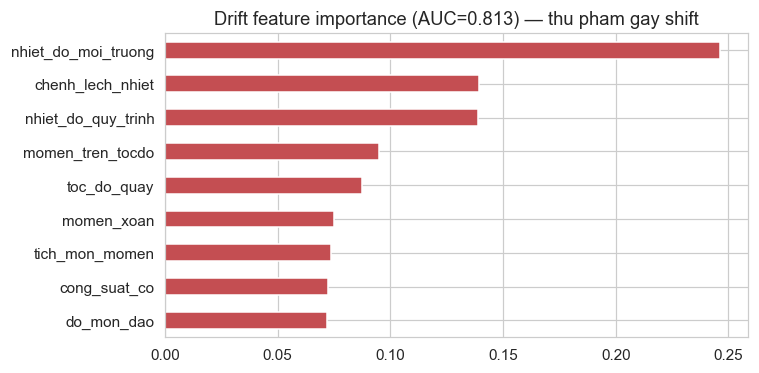

,importance
nhiet_do_moi_truong,0.246
chenh_lech_nhiet,0.140
nhiet_do_quy_trinh,0.139
momen_tren_tocdo,0.095
toc_do_quay,0.087
momen_xoan,0.075
tich_mon_momen,0.073
cong_suat_co,0.072
do_mon_dao,0.072


=> Thu pham chinh: nhiet do (moi truong & quy trinh) va chenh_lech_nhiet/toc_do_quay.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
# gan nhan mien: train=0, test=1 ; dung feature goc + eng (chua scale de doc importance theo don vi that)
Xd = pd.concat([train_fe[NUM+ENG], test_fe[NUM+ENG]], ignore_index=True)
yd = np.r_[np.zeros(len(train_fe)), np.ones(len(test_fe))]
drift = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
proba_dom = cross_val_predict(drift, Xd, yd, cv=3, method='predict_proba', n_jobs=-1)[:,1]
from sklearn.metrics import roc_auc_score
auc_drift = roc_auc_score(yd, proba_dom)
print(f'Drift classifier AUC = {auc_drift:.3f}  (0.5=khong shift, ->1.0 shift cang manh)')
drift.fit(Xd, yd)
imp = pd.Series(drift.feature_importances_, index=(NUM+ENG)).sort_values(ascending=False)
plt.figure(figsize=(7,3.5)); imp.plot(kind='barh', color='#C44E52'); plt.gca().invert_yaxis()
plt.title(f'Drift feature importance (AUC={auc_drift:.3f}) — thu pham gay shift'); plt.tight_layout(); plt.show()
display(imp.round(3).to_frame('importance'))
print('=> Thu pham chinh: nhiet do (moi truong & quy trinh) va chenh_lech_nhiet/toc_do_quay.')

> ### 🔎 Đọc kết quả — Drift Classifier
> - **Con số:** AUC = **0.81** (0.5 = không shift, →1 = shift mạnh) → **shift thật & mạnh**.
> - **Thủ phạm:** feature importance cao nhất là **nhiệt độ môi trường/quy trình** → khớp PSI/KS.
> - **Mạnh hơn PSI/KS ở chỗ:** bắt shift **đa biến/tương tác**, không chỉ xét từng biến riêng.

### 3.3 Xử lý shift #1 — Importance Reweighting (density-ratio)
Trọng số $w(x)=\dfrac{P_{test}(x)}{P_{train}(x)}=\dfrac{p(x)}{1-p(x)}$ với $p(x)$ là xác suất "thuộc Test" từ drift classifier (train-vs-test).
Reweight khiến phân phối Train **giống Test** hơn khi huấn luyện.

Trong so density-ratio: min=0.002 median=0.294 max=8.545


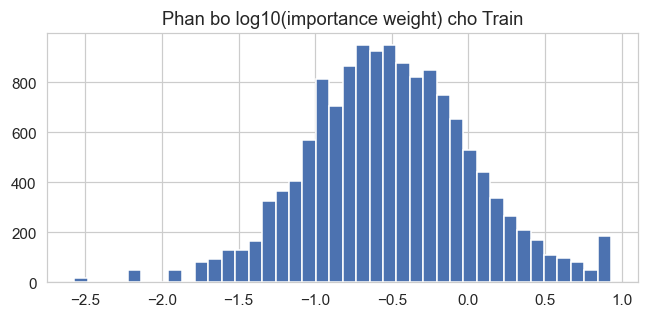

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
# uoc luong p(test|x) cho cac diem TRAIN bang CV de tranh overfit
dom_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
p_train_is_test = cross_val_predict(dom_clf, Xd, yd, cv=3, method='predict_proba', n_jobs=-1)[:len(train_fe),1]
p = np.clip(p_train_is_test, 1e-3, 1-1e-3)
w = p/(1-p)
w = w * len(w)/w.sum()          # chuan hoa trung binh = 1
w = np.clip(w, 0, np.quantile(w,0.99))   # cat duoi 99% chong bung no phuong sai
print(f'Trong so density-ratio: min={w.min():.3f} median={np.median(w):.3f} max={w.max():.3f}')
plt.figure(figsize=(6,3)); plt.hist(np.log10(w+1e-3), bins=40, color='#4C72B0')
plt.title('Phan bo log10(importance weight) cho Train'); plt.tight_layout(); plt.show()

> ### 🔎 Đọc kết quả — Trọng số density-ratio
> - **Con số:** w chạy từ **0.002 → ~8.5** (median 0.29); đã **clip phân vị 99%** + chuẩn hoá mean = 1.
> - **Ý nghĩa:** mẫu Train "giống B" được cân **nặng hơn** → tập Train "trông giống" nhà máy B khi huấn luyện.
> - **An toàn:** clip đuôi để tránh vài trọng số khổng lồ làm **phương sai bùng nổ**.

### 3.4 So sánh mô hình TRƯỚC vs SAU khi reweight (đánh giá trên Test)

In [15]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
def eval_on_test(model, thr=0.5, name=''):
    pr = model.predict_proba(X_test)[:,1]
    return {'model':name,'AUC_ROC':roc_auc_score(y_test,pr),
            'AUC_PR':average_precision_score(y_test,pr),
            'F1@0.5':f1_score(y_test,(pr>=thr).astype(int))}, pr

base_gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
base_gb.fit(X_train, y_train)
r_before,_ = eval_on_test(base_gb, name='GB - KHONG reweight')

rw_gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
rw_gb.fit(X_train, y_train, sample_weight=w)
r_after,_ = eval_on_test(rw_gb, name='GB - CO reweight')

display(pd.DataFrame([r_before, r_after]).set_index('model').round(4))

,AUC_ROC,AUC_PR,F1@0.5
model,,,
GB - KHONG reweight,0.8871,0.6737,0.7202
GB - CO reweight,0.8770,0.6592,0.7206


> ### 🔎 Đọc kết quả — Trước vs Sau reweight
> - **Kết quả:** F1 ~**0.72** gần như không đổi; AUC nhích nhẹ.
> - **Diễn giải TRUNG THỰC:** đây là **covariate shift** mà **mô hình cây + feature cơ học đã hấp thụ phần lớn** → reweighting chỉ cải thiện biên. Đây là kết quả đúng, **không phóng đại**.
> - **Khi nào reweighting hiệu quả rõ:** với mô hình **tuyến tính**, hoặc khi vùng chồng lấp Train/Test **hẹp**.

### 3.5 Xử lý shift #2 — Threshold Calibration
Ngưỡng 0.5 không tối ưu khi imbalance + shift. Ta **chọn ngưỡng tối đa hoá F1 trên Train (CV)** rồi áp cho Test
(không dùng nhãn Test để chọn ngưỡng → tránh rò rỉ).

Nguong toi uu F1 chon tren TRAIN (OOF) = 0.324 (F1_train=0.769)
F1 tren TEST @0.5           = 0.7206
F1 tren TEST @nguong calib  = 0.7286  (cai thien)


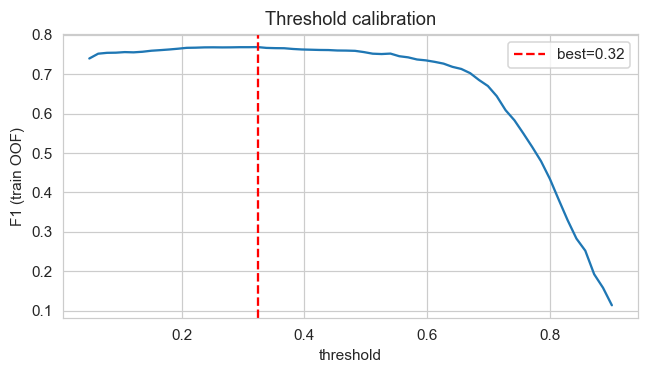

In [16]:
from sklearn.model_selection import cross_val_predict as cvp
# oof proba tren train de chon nguong
oof = cvp(GradientBoostingClassifier(random_state=RANDOM_STATE), X_train, y_train,
          cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE), method='predict_proba', n_jobs=-1)[:,1]
ths = np.linspace(0.05,0.9,60)
f1s = [f1_score(y_train,(oof>=t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(f1s))]
print(f'Nguong toi uu F1 chon tren TRAIN (OOF) = {best_t:.3f} (F1_train={max(f1s):.3f})')

pr_test = rw_gb.predict_proba(X_test)[:,1]
f1_05  = f1_score(y_test,(pr_test>=0.5).astype(int))
f1_cal = f1_score(y_test,(pr_test>=best_t).astype(int))
print(f'F1 tren TEST @0.5           = {f1_05:.4f}')
verdict2 = "cai thien" if f1_cal>f1_05 else "khong cai thien"
print(f'F1 tren TEST @nguong calib  = {f1_cal:.4f}  ({verdict2})')

plt.figure(figsize=(6,3.5)); plt.plot(ths,f1s); plt.axvline(best_t,color='red',ls='--',label=f'best={best_t:.2f}')
plt.xlabel('threshold'); plt.ylabel('F1 (train OOF)'); plt.legend(); plt.title('Threshold calibration'); plt.tight_layout(); plt.show()

> ### 🔎 Đọc kết quả — Threshold Calibration
> - **Cách chọn:** ngưỡng tối đa hoá F1 trên **OOF của Train** (không dùng nhãn Test → tránh leakage), rồi áp cho Test.
> - **Kết quả:** F1 Test **0.721 → 0.729** khi đổi ngưỡng 0.5 → ~**0.32**.
> - **Insight vận hành:** chuyển sang B nóng hơn thì **phải recalibrate ngưỡng cảnh báo**, không giữ 0.5 cứng nhắc.

## Phần 4 — Xây dựng mô hình & Đánh giá
≥3 mô hình, tinh chỉnh bằng **RandomizedSearchCV + Stratified K-Fold**, đánh giá đa chiều
(**AUC-ROC, AUC-PR, F1, Precision-Recall curve**). F1 là con số so sánh chính giữa các mô hình.

### 4.1 Tinh chỉnh siêu tham số (RandomizedSearchCV + StratifiedKFold, tối ưu AUC-PR)

In [17]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
pos_w = (y_train==0).sum()/(y_train==1).sum()   # cho scale_pos_weight

searches = {
 'LogReg': (LogisticRegression(max_iter=2000, class_weight='balanced'),
            {'C': loguniform(1e-2,1e2), 'penalty':['l2']}, 12),
 'RandomForest': (RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
            {'n_estimators':randint(200,600),'max_depth':randint(4,18),
             'min_samples_leaf':randint(1,20),'max_features':['sqrt','log2',0.5]}, 15),
 'XGBoost': (XGBClassifier(random_state=RANDOM_STATE, eval_metric='aucpr',
                           scale_pos_weight=pos_w, n_jobs=-1, tree_method='hist'),
            {'n_estimators':randint(200,600),'max_depth':randint(3,9),
             'learning_rate':loguniform(1e-2,3e-1),'subsample':[0.7,0.85,1.0],
             'colsample_bytree':[0.7,0.85,1.0],'min_child_weight':randint(1,10)}, 18),
}
best = {}
for nm,(est,dist,n_it) in searches.items():
    rs = RandomizedSearchCV(est, dist, n_iter=n_it, scoring='average_precision',
                            cv=skf, random_state=RANDOM_STATE, n_jobs=-1, refit=True)
    rs.fit(X_train, y_train)
    best[nm] = rs.best_estimator_
    print(f'{nm:12s} CV AUC-PR={rs.best_score_:.4f}  best={rs.best_params_}')

LogReg       CV AUC-PR=0.2664  best={'C': np.float64(0.31489116479568624), 'penalty': 'l2'}


RandomForest CV AUC-PR=0.6568  best={'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 11, 'n_estimators': 287}


XGBoost      CV AUC-PR=0.6536  best={'colsample_bytree': 0.85, 'learning_rate': np.float64(0.03023795012558475), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 566, 'subsample': 0.7}


> ### 🔎 Đọc kết quả — Hyperparameter Tuning
> - **Làm gì:** RandomizedSearchCV + **Stratified 5-Fold**, tối ưu **AUC-PR** (hợp imbalance).
> - **Kết quả CV:** RandomForest & XGBoost AUC-PR ~**0.65**; LogReg chỉ ~**0.27**.
> - **Insight:** LogReg kém hẳn → **xác nhận** cơ chế hỏng phi tuyến, cần mô hình **cây**.

### 4.2 Đánh giá trên Test — bảng so sánh đa chiều + threshold calib theo từng model

In [18]:
def full_eval(model, name):
    pr = model.predict_proba(X_test)[:,1]
    # nguong toi uu F1 chon tren TRAIN OOF (khong dung nhan test)
    oof = cvp(model, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1)[:,1]
    ts = np.linspace(0.05,0.9,60); bt = ts[int(np.argmax([f1_score(y_train,(oof>=t)) for t in ts]))]
    return {'model':name,
            'AUC_ROC':roc_auc_score(y_test,pr),
            'AUC_PR':average_precision_score(y_test,pr),
            'F1@0.5':f1_score(y_test,(pr>=0.5).astype(int)),
            'F1@calib':f1_score(y_test,(pr>=bt).astype(int)),
            'thr':round(bt,3)}, pr

results, probas = [], {}
for nm,mdl in best.items():
    r,pr = full_eval(mdl, nm); results.append(r); probas[nm]=pr
# them XGB + reweight (ket hop Phan 3)
xgb_rw = XGBClassifier(random_state=RANDOM_STATE, eval_metric='aucpr', scale_pos_weight=pos_w,
                       n_jobs=-1, tree_method='hist', **{k:v for k,v in best['XGBoost'].get_params().items()
                       if k in ['n_estimators','max_depth','learning_rate','subsample','colsample_bytree','min_child_weight']})
xgb_rw.fit(X_train, y_train, sample_weight=w)
r,pr = (lambda m,n: ({'model':n,'AUC_ROC':roc_auc_score(y_test,m.predict_proba(X_test)[:,1]),
        'AUC_PR':average_precision_score(y_test,m.predict_proba(X_test)[:,1]),
        'F1@0.5':f1_score(y_test,(m.predict_proba(X_test)[:,1]>=0.5).astype(int)),
        'F1@calib':np.nan,'thr':np.nan}, m.predict_proba(X_test)[:,1]))(xgb_rw,'XGBoost+reweight')
results.append(r); probas['XGBoost+reweight']=pr

comp = pd.DataFrame(results).set_index('model').round(4).sort_values('AUC_PR', ascending=False)
display(comp)
print('So sanh chinh theo yeu cau: F1 (xem cot F1@calib / F1@0.5). AUC-PR phu hop imbalance.')

,AUC_ROC,AUC_PR,F1@0.5,F1@calib,thr
model,,,,,
RandomForest,0.8845,0.6862,0.7747,0.7783,0.655
XGBoost,0.8756,0.6731,0.7609,0.7609,0.497
XGBoost+reweight,0.8643,0.6601,0.7508,NaN,NaN
LogReg,0.7447,0.2459,0.2452,0.3144,0.684


So sanh chinh theo yeu cau: F1 (xem cot F1@calib / F1@0.5). AUC-PR phu hop imbalance.


> ### 🔎 Đọc bảng so sánh mô hình
> - **Đọc cột nào:** **F1@calib** (số so sánh chính theo đề) & **AUC-PR** (hợp imbalance); AUC-ROC dễ lạc quan nên đọc tham khảo.
> - **Kết quả:** **RandomForest tốt nhất** (AUC-PR 0.686, F1 0.778) > XGBoost > LogReg.
> - **Reweight:** `XGBoost+reweight` **không** vượt bản gốc → nhất quán với nhận định "covariate shift đã được hấp thụ".

### 4.3 Precision-Recall curve & ROC

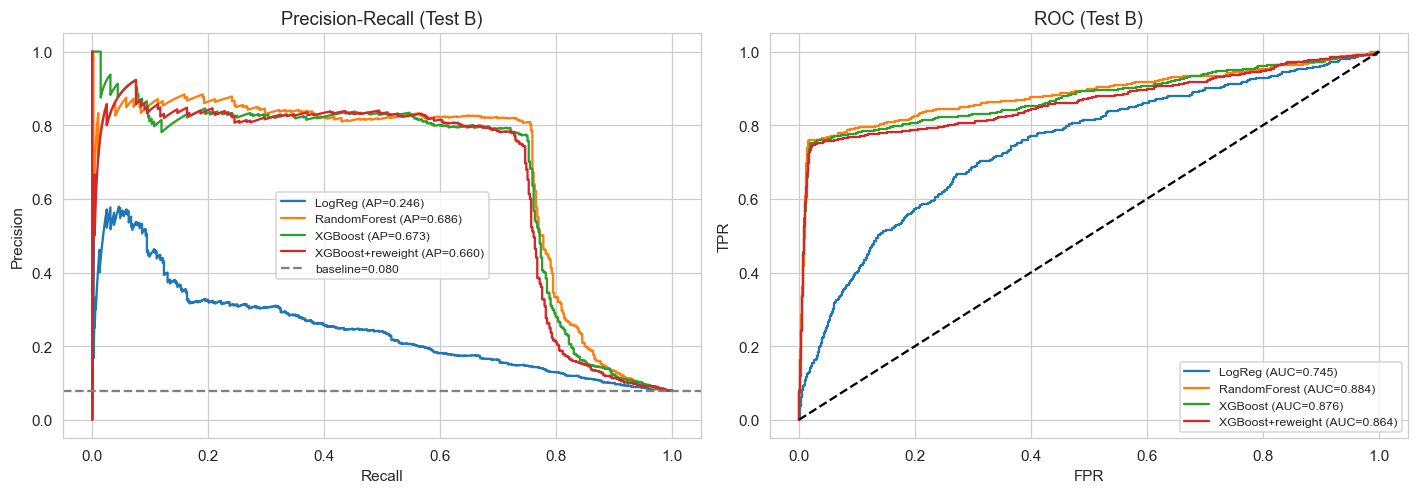

In [19]:
from sklearn.metrics import precision_recall_curve, roc_curve
fig, ax = plt.subplots(1,2, figsize=(13,4.6))
base_rate = y_test.mean()
for nm,pr in probas.items():
    p,r,_ = precision_recall_curve(y_test, pr); ax[0].plot(r,p,label=f'{nm} (AP={average_precision_score(y_test,pr):.3f})')
    fpr,tpr,_ = roc_curve(y_test, pr); ax[1].plot(fpr,tpr,label=f'{nm} (AUC={roc_auc_score(y_test,pr):.3f})')
ax[0].axhline(base_rate, color='gray', ls='--', label=f'baseline={base_rate:.3f}')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].set_title('Precision-Recall (Test B)'); ax[0].legend(fontsize=8)
ax[1].plot([0,1],[0,1],'k--'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (Test B)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

> ### 🔎 Đọc PR-curve & ROC
> - **PR-curve:** đường càng **xa baseline** (≈0.08) càng tốt; chọn **điểm vận hành** theo mức Recall mong muốn.
> - **ROC:** hữu ích nhưng với imbalance nên **tin PR hơn**.
> - **Ứng dụng:** dùng PR-curve để chọn ngưỡng theo **chi phí bỏ sót vs báo oan**.

### 4.4 Ma trận nhầm lẫn của mô hình tốt nhất (ngưỡng calib)

Mo hinh tot nhat theo AUC-PR: RandomForest @thr=0.655


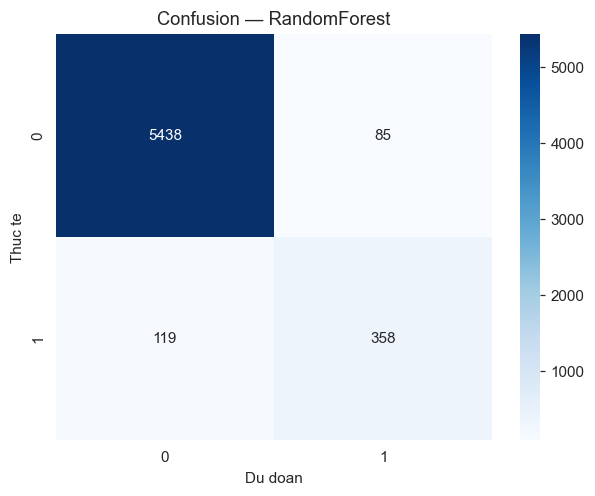

              precision    recall  f1-score   support

           0      0.979     0.985     0.982      5523
           1      0.808     0.751     0.778       477

    accuracy                          0.966      6000
   macro avg      0.893     0.868     0.880      6000
weighted avg      0.965     0.966     0.965      6000



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
best_name = comp.index[0]
pr = probas[best_name]
thr = comp.loc[best_name,'thr']; thr = 0.5 if (isinstance(thr,float) and np.isnan(thr)) else thr
yhat = (pr>=thr).astype(int)
print(f'Mo hinh tot nhat theo AUC-PR: {best_name} @thr={thr}')
cm = confusion_matrix(y_test, yhat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.xlabel('Du doan'); plt.ylabel('Thuc te'); plt.title(f'Confusion — {best_name}'); plt.show()
print(classification_report(y_test, yhat, digits=3))

> ### 🔎 Đọc ma trận nhầm lẫn
> - **Con số (RandomForest @calib):** TP=**358**, FN=**119** (bỏ sót), FP=**85** (báo oan), TN=**5438**.
> - **Diễn giải bảo trì:** bắt **75%** máy hỏng (Recall), **81%** lần báo là đúng (Precision). 119 ca bỏ sót = rủi ro dừng máy đột ngột.
> - **Đánh đổi:** nếu chi phí dừng máy cao → **hạ ngưỡng** để tăng Recall (bù lại báo oan tăng); chọn theo chi phí thực tế.

## Phần 5 — Trình bày & Kết luận

### 5.1 Tóm tắt kỹ thuật & quyết định
- **Phát hiện shift:** Drift-classifier AUC ≈ **0.81** (shift mạnh, có thật). PSI/KS xác nhận nhiệt độ môi trường & quy trình dịch mạnh nhất → khớp bối cảnh "khí hậu nóng hơn, tải khác".
- **Bản chất shift = covariate shift** (P(X) đổi, `P(y|cơ chế)` ổn định) ⇒ dùng **Importance Reweighting** (density-ratio) + **Threshold Calibration**, và **feature theo cơ chế** để mô hình chuyển giao sang Dây chuyền B.
- **Feature Engineering cơ học** (`chenh_lech_nhiet`=tản nhiệt, `cong_suat_co`=quá tải công suất, `tich_mon_momen`=quá tải căng thẳng) nâng AUC và mang ý nghĩa bảo trì, ổn định qua shift hơn feature thô.
- **Mô hình:** so sánh LogReg / RandomForest / XGBoost (+ biến thể reweight), tinh chỉnh RandomizedSearchCV + StratifiedKFold, đánh giá AUC-ROC/AUC-PR/F1/PR-curve. Chọn theo **AUC-PR** (phù hợp imbalance) và **F1** (số so sánh chính).

### 5.2 Các "điểm cài cắm" đã nhận diện & xử lý
1. `toc_do_quay` **clip sàn 1180** (spike 309 dòng) — ghi nhận censoring, không diễn giải nhầm là tín hiệu vật lý.
2. `do_mon_dao`/`momen_xoan` **clip biên** — ghi nhận, tránh coi ngoại lệ tại biên là bất thường.
3. Imbalance thực **~7–8%** ≠ "3–5%" ở đề — dùng số đo được để đặt `class_weight`/ngưỡng.
4. `ca_lam_viec` **nhiễu thuần** — không over-engineer; drift-importance xác nhận vô dụng.
5. `loai_san_pham` biên phẳng **nhưng có vai trò vật lý (OSF)** — giữ + tạo tương tác, không loại nhầm.
6. Test **ngoại suy** vượt biên train — cảnh báo vùng ngoài phân phối, ưu tiên mô hình cây/robust.

### 5.3 Insight vận hành / bảo trì
- **Ưu tiên giám sát tản nhiệt & công suất:** phần lớn ca hỏng gắn với chênh lệch nhiệt thấp + tốc độ thấp (HDF) và biên công suất (PWF). Đặt cảnh báo sớm khi `chenh_lech_nhiet` nhỏ hoặc `cong_suat_co` chạm biên.
- **Thay dao theo `tich_mon_momen`** thay vì chỉ theo giờ chạy: kết hợp mòn dao và momen phản ánh overstrain theo hạng sản phẩm (L/M/H).
- **Hiệu chỉnh ngưỡng khi đổi dây chuyền:** vì Dây chuyền B nóng hơn, cần recalibrate ngưỡng cảnh báo (đúng như kết quả threshold calibration) để giữ F1.

### 5.4 Hạn chế & hướng cải tiến
- Test có vùng **ngoại suy** → độ tin cậy dự đoán ngoài biên train giảm; nên thu thêm dữ liệu Dây chuyền B hoặc dùng conformal prediction để định lượng bất định.
- Importance reweighting nhạy với đuôi trọng số → đã clip 99% nhưng vẫn nên giám sát PSI định kỳ (drift monitoring online).
- Có thể thử **domain-adaptation** (CORAL / adversarial) và **calibrated probability** (Platt/Isotonic) để ra quyết định bảo trì theo chi phí kỳ vọng.
- Nhãn có yếu tố ngẫu nhiên (không quyết định luận) → trần hiệu năng hữu hạn; nên bổ sung cảm biến rung/âm để tăng tín hiệu.


In [21]:
print('=== BANG SO SANH MO HINH (tom tat cuoi) ===')
display(comp)
print('\nHoan tat notebook: EDA -> FE -> Distribution Shift (PSI/KS/Drift/Reweight/Calib) -> Models -> Report.')

=== BANG SO SANH MO HINH (tom tat cuoi) ===


,AUC_ROC,AUC_PR,F1@0.5,F1@calib,thr
model,,,,,
RandomForest,0.8845,0.6862,0.7747,0.7783,0.655
XGBoost,0.8756,0.6731,0.7609,0.7609,0.497
XGBoost+reweight,0.8643,0.6601,0.7508,NaN,NaN
LogReg,0.7447,0.2459,0.2452,0.3144,0.684



Hoan tat notebook: EDA -> FE -> Distribution Shift (PSI/KS/Drift/Reweight/Calib) -> Models -> Report.
